# Diabetes Health Indicators — Complete Data Mining & Classification Analysis

**Dataset:** Diabetes Health Indicators Dataset (BRFSS 2015)

**Objective:** Explore relationships between demographic, lifestyle, and health indicators and diabetes status; assess data quality; identify potential risk indicators; build multiclass classification models; evaluate them using metrics appropriate for class imbalance; and summarize the findings.

**Target:** `Diabetes_012` — 0 = No diabetes, 1 = Prediabetes, 2 = Diabetes.

> **Dataset note:** The supplied CSV contains **22 columns total**: 21 predictors and 1 target. The notebook uses the supplied file as the source of truth.

**GenAI-assisted component:** Generative AI is used to help structure the analysis, explain findings, and draft narrative. All numerical results and charts are calculated directly from the supplied dataset.

## 1. Import Libraries and Configuration

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, classification_report, confusion_matrix
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_FILE = "diabetes_012_health_indicators_BRFSS2015(1).csv"

if not os.path.exists(DATA_FILE):
    for path in [
        "diabetes_012_health_indicators_BRFSS2015.csv",
        "/mnt/data/diabetes_012_health_indicators_BRFSS2015(1).csv"
    ]:
        if os.path.exists(path):
            DATA_FILE = path
            break

print("Using dataset:", DATA_FILE)

Using dataset: diabetes_012_health_indicators_BRFSS2015(1).csv


## 2. Load the Dataset

In [2]:
df = pd.read_csv(DATA_FILE)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Rows: 253,680
Columns: 22


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 3. Dataset Structure and Data Types

In [3]:
df.info()
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

,dtype
Diabetes_012,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64



Shape: (253680, 22)

Columns: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


## 4. Descriptive Statistics

In [4]:
display(df.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.297,0.698,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429,0.495,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424,0.494,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.963,0.190,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382,6.609,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443,0.497,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.041,0.197,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094,0.292,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.757,0.429,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634,0.482,0.0,0.0,1.0,1.0,1.0


## 5. Data Quality Checks

This section checks missing values, duplicates, and basic value validity. Missing-value handling is based on the actual supplied data rather than assuming that imputation is required.

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_pct.round(2)
})

print("Total missing cells:", int(df.isna().sum().sum()))
display(missing_summary[missing_summary["Missing_Count"] > 0])

duplicate_count = int(df.duplicated().sum())
print(f"Exact duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")

binary_columns = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost",
    "DiffWalk", "Sex"
]
binary_check = {c: sorted(df[c].dropna().unique().tolist()) for c in binary_columns if c in df}
display(pd.DataFrame(dict([(k, pd.Series(v)) for k, v in binary_check.items()])))

target_before = df["Diabetes_012"].value_counts().sort_index()
target_before_pct = df["Diabetes_012"].value_counts(normalize=True).sort_index() * 100
display(pd.DataFrame({
    "Count": target_before,
    "Percentage": target_before_pct.round(2)
}).rename(index={0.0:"No diabetes", 1.0:"Prediabetes", 2.0:"Diabetes"}))

Total missing cells: 0


,Missing_Count,Missing_Percentage


Exact duplicate rows: 23,899
Duplicate percentage: 9.42%


,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


,Count,Percentage
Diabetes_012,,
No diabetes,213703,84.24
Prediabetes,4631,1.83
Diabetes,35346,13.93


## 6. Data Cleaning

The supplied dataset contains no missing cells, so **no imputation is performed**.

There are exact duplicate rows. These are removed before modeling to avoid allowing repeated identical observations to influence the analysis disproportionately.

In [6]:
df_clean = df.drop_duplicates().reset_index(drop=True).copy()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape:  {df_clean.shape}")
print(f"Rows removed as exact duplicates: {len(df) - len(df_clean):,}")
print("Missing cells after cleaning:", int(df_clean.isna().sum().sum()))

target_after = df_clean["Diabetes_012"].value_counts().sort_index()
target_after_pct = df_clean["Diabetes_012"].value_counts(normalize=True).sort_index() * 100
target_summary = pd.DataFrame({
    "Count": target_after,
    "Percentage": target_after_pct.round(2)
})
target_summary.index = ["No diabetes", "Prediabetes", "Diabetes"]
display(target_summary)

Original shape: (253680, 22)
Cleaned shape:  (229781, 22)
Rows removed as exact duplicates: 23,899
Missing cells after cleaning: 0


,Count,Percentage
No diabetes,190055,82.71
Prediabetes,4629,2.01
Diabetes,35097,15.27


## 7. Target Variable Analysis

The target is highly imbalanced. This matters because a model can obtain high overall accuracy by favoring the majority class. Therefore, later evaluation includes balanced accuracy, macro precision, macro recall, macro F1, and confusion matrices—not accuracy alone.

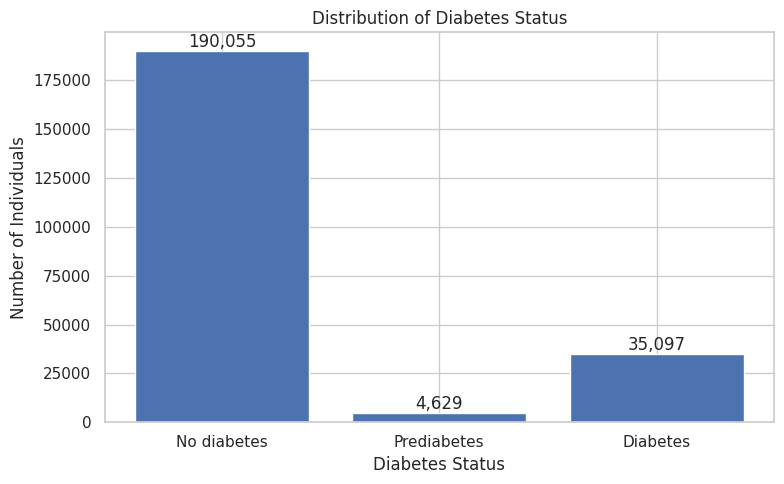

,Count,Percentage
No diabetes,190055,82.71
Prediabetes,4629,2.01
Diabetes,35097,15.27


In [7]:
plt.figure(figsize=(8, 5))
counts = df_clean["Diabetes_012"].value_counts().sort_index()
labels = ["No diabetes", "Prediabetes", "Diabetes"]
plt.bar(labels, counts.values)
plt.title("Distribution of Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Individuals")
for i, value in enumerate(counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()
display(target_summary)

## 8. Exploratory Data Analysis

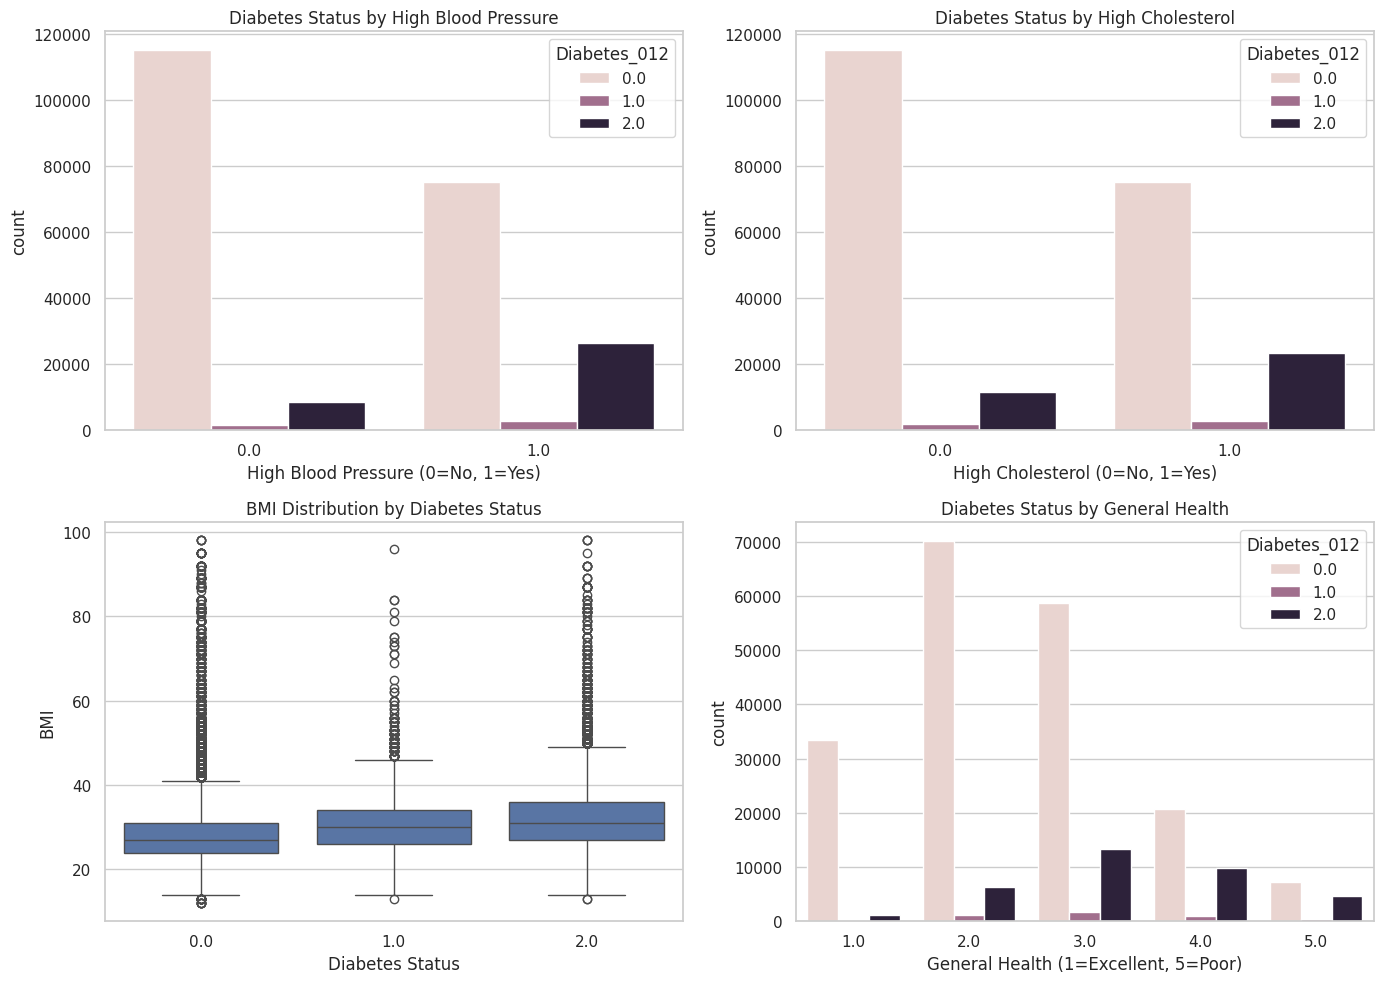

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_clean, x="HighBP", hue="Diabetes_012", ax=axes[0, 0])
axes[0, 0].set_title("Diabetes Status by High Blood Pressure")
axes[0, 0].set_xlabel("High Blood Pressure (0=No, 1=Yes)")

sns.countplot(data=df_clean, x="HighChol", hue="Diabetes_012", ax=axes[0, 1])
axes[0, 1].set_title("Diabetes Status by High Cholesterol")
axes[0, 1].set_xlabel("High Cholesterol (0=No, 1=Yes)")

sns.boxplot(data=df_clean, x="Diabetes_012", y="BMI", ax=axes[1, 0])
axes[1, 0].set_title("BMI Distribution by Diabetes Status")
axes[1, 0].set_xlabel("Diabetes Status")

sns.countplot(data=df_clean, x="GenHlth", hue="Diabetes_012", ax=axes[1, 1])
axes[1, 1].set_title("Diabetes Status by General Health")
axes[1, 1].set_xlabel("General Health (1=Excellent, 5=Poor)")

plt.tight_layout()
plt.show()

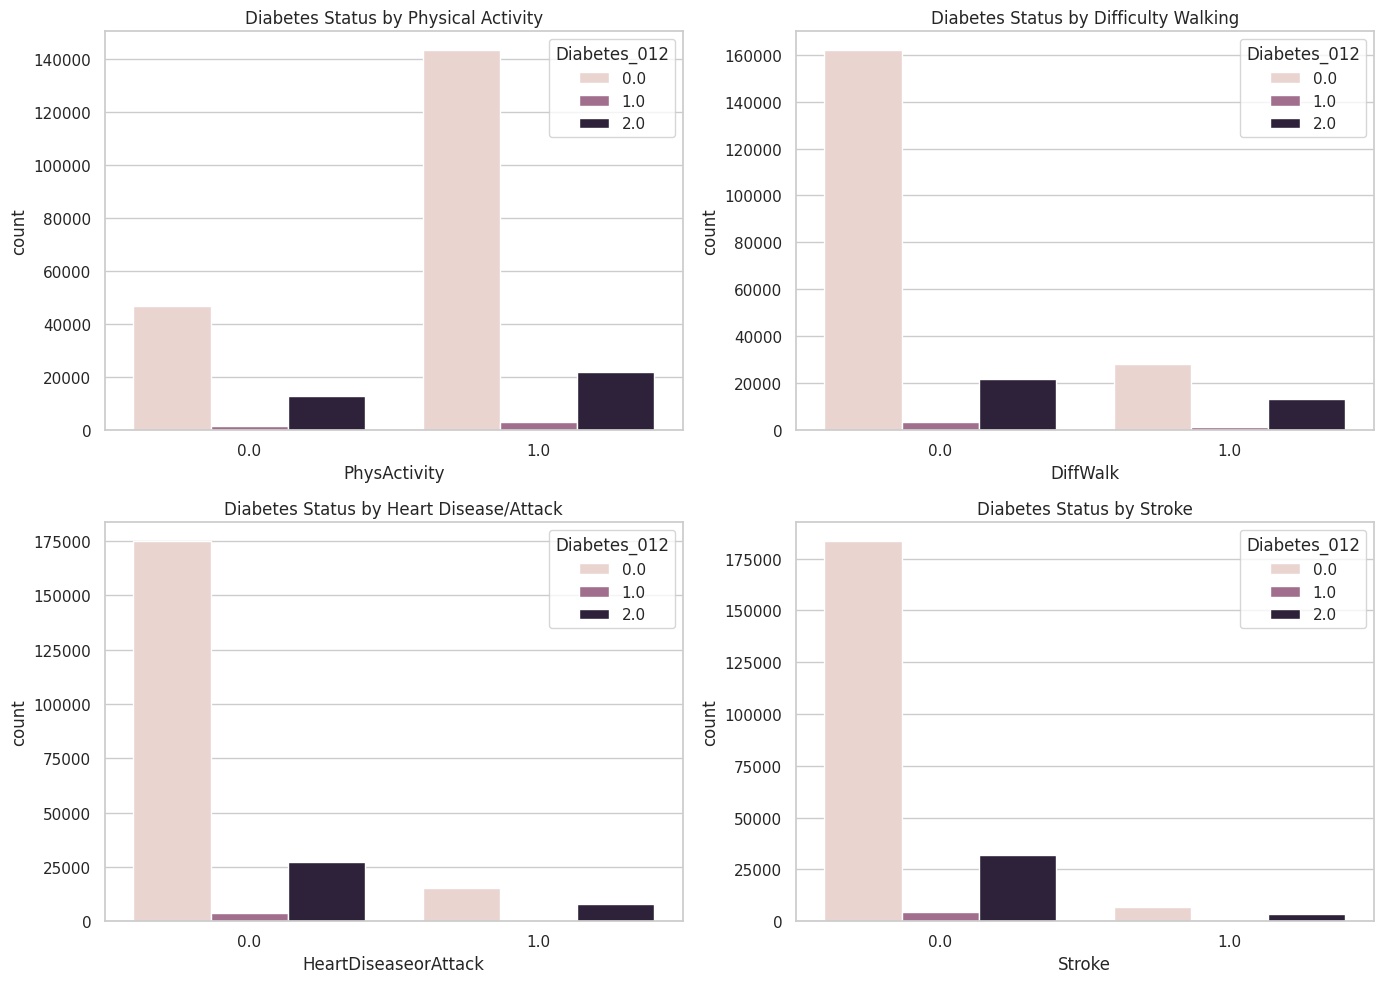

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_clean, x="PhysActivity", hue="Diabetes_012", ax=axes[0, 0])
axes[0, 0].set_title("Diabetes Status by Physical Activity")

sns.countplot(data=df_clean, x="DiffWalk", hue="Diabetes_012", ax=axes[0, 1])
axes[0, 1].set_title("Diabetes Status by Difficulty Walking")

sns.countplot(data=df_clean, x="HeartDiseaseorAttack", hue="Diabetes_012", ax=axes[1, 0])
axes[1, 0].set_title("Diabetes Status by Heart Disease/Attack")

sns.countplot(data=df_clean, x="Stroke", hue="Diabetes_012", ax=axes[1, 1])
axes[1, 1].set_title("Diabetes Status by Stroke")

plt.tight_layout()
plt.show()

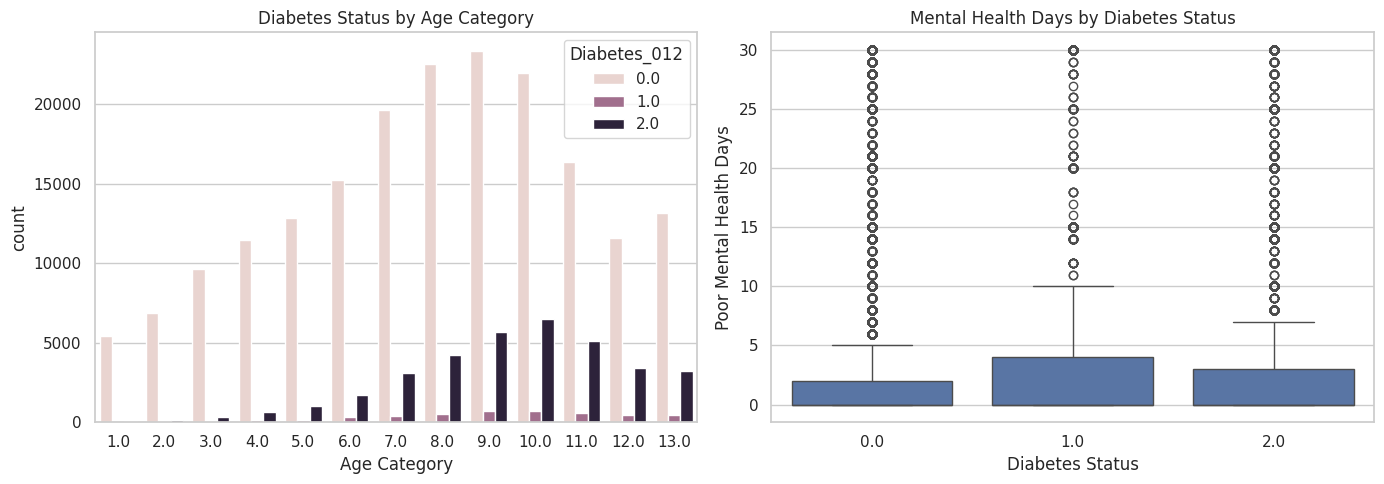

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, x="Age", hue="Diabetes_012", ax=axes[0])
axes[0].set_title("Diabetes Status by Age Category")
axes[0].set_xlabel("Age Category")

sns.boxplot(data=df_clean, x="Diabetes_012", y="MentHlth", ax=axes[1])
axes[1].set_title("Mental Health Days by Diabetes Status")
axes[1].set_xlabel("Diabetes Status")
axes[1].set_ylabel("Poor Mental Health Days")

plt.tight_layout()
plt.show()

## 9. Relationship Analysis and Risk Indicators

For binary indicators, the group mean is the prevalence within that diabetes group. These results describe associations and should not be interpreted as evidence of causation.

In [11]:
risk_variables = [
    "BMI", "HighBP", "HighChol", "GenHlth", "Age",
    "DiffWalk", "HeartDiseaseorAttack", "Stroke",
    "PhysActivity", "PhysHlth", "MentHlth",
    "Smoker", "Fruits", "Veggies", "HvyAlcoholConsump"
]

group_summary = df_clean.groupby("Diabetes_012")[risk_variables].mean().T
group_summary.columns = ["No diabetes", "Prediabetes", "Diabetes"]
display(group_summary.round(3))

,No diabetes,Prediabetes,Diabetes
BMI,28.031,30.726,31.964
HighBP,0.395,0.629,0.752
HighChol,0.395,0.621,0.669
GenHlth,2.464,2.976,3.296
Age,7.824,9.082,9.376
DiffWalk,0.149,0.278,0.374
HeartDiseaseorAttack,0.080,0.143,0.224
Stroke,0.036,0.057,0.093
PhysActivity,0.754,0.678,0.629
PhysHlth,4.019,6.351,8.008


In [12]:
risk_compare = pd.DataFrame({
    "No_Diabetes": df_clean[df_clean["Diabetes_012"] == 0][risk_variables].mean(),
    "Prediabetes": df_clean[df_clean["Diabetes_012"] == 1][risk_variables].mean(),
    "Diabetes": df_clean[df_clean["Diabetes_012"] == 2][risk_variables].mean()
})
risk_compare["Diabetes_minus_NoDiabetes"] = (
    risk_compare["Diabetes"] - risk_compare["No_Diabetes"]
)
display(risk_compare.sort_values("Diabetes_minus_NoDiabetes", ascending=False).round(3))

,No_Diabetes,Prediabetes,Diabetes,Diabetes_minus_NoDiabetes
PhysHlth,4.019,6.351,8.008,3.990
BMI,28.031,30.726,31.964,3.934
Age,7.824,9.082,9.376,1.552
MentHlth,3.298,4.532,4.493,1.195
GenHlth,2.464,2.976,3.296,0.832
HighBP,0.395,0.629,0.752,0.357
HighChol,0.395,0.621,0.669,0.274
DiffWalk,0.149,0.278,0.374,0.225
HeartDiseaseorAttack,0.080,0.143,0.224,0.144
Smoker,0.455,0.493,0.519,0.064


## 10. Correlation Analysis

The correlation matrix is an exploratory summary. Several variables are binary or ordinal encodings, so correlations should be interpreted as associations in the encoded data rather than causal effects.

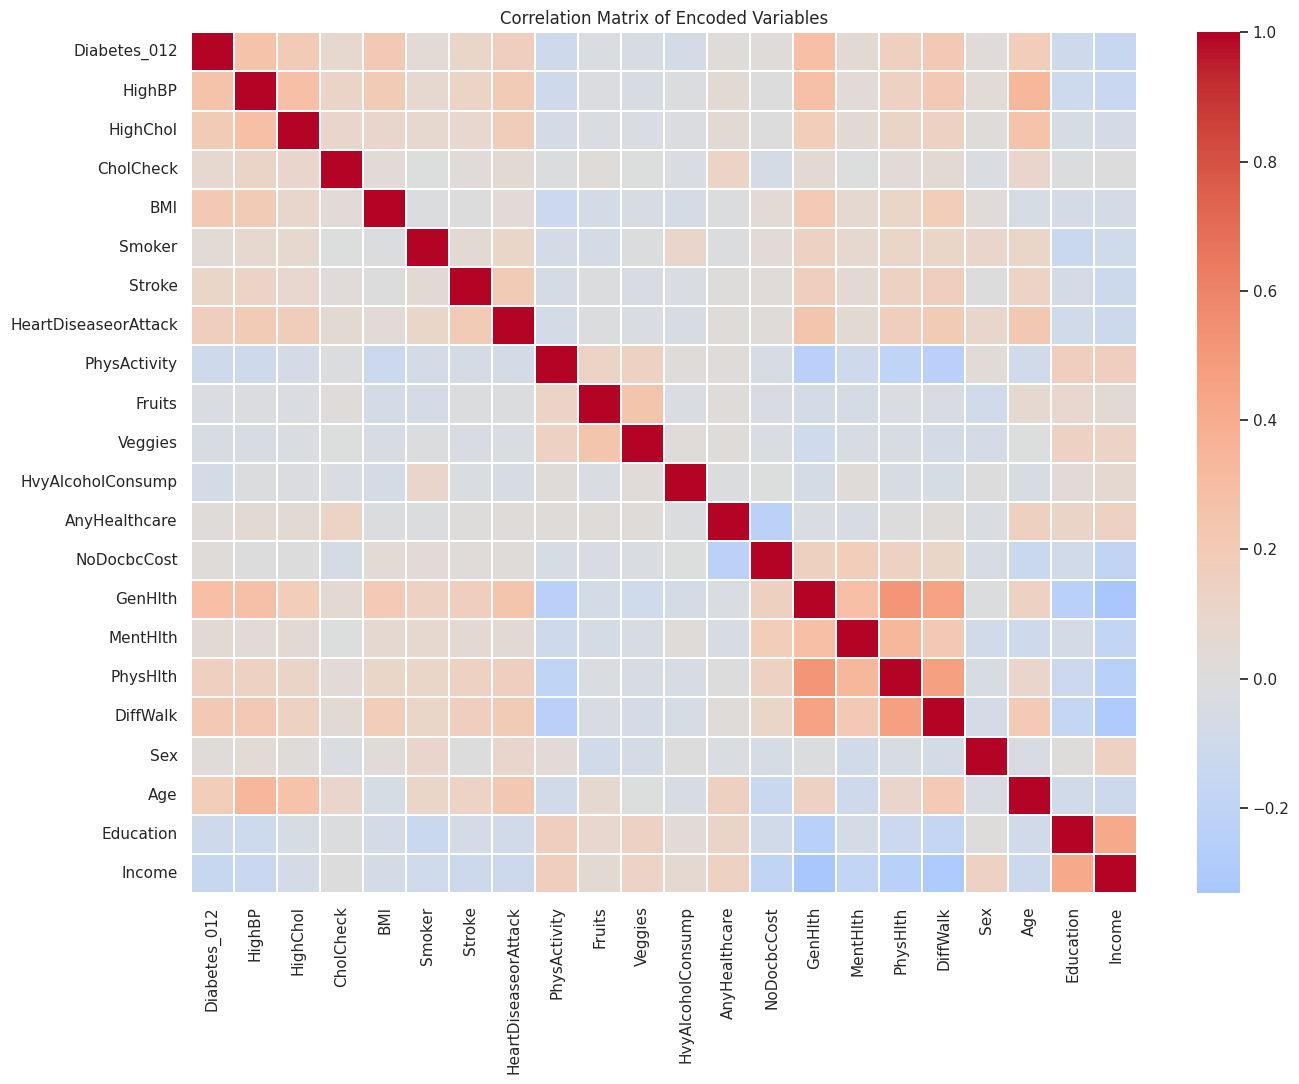

Most positive associations:


,Correlation
GenHlth,0.284881
HighBP,0.261976
BMI,0.212027
DiffWalk,0.210638
HighChol,0.203327
Age,0.184642
HeartDiseaseorAttack,0.170816
PhysHlth,0.160485
Stroke,0.100276
CholCheck,0.075701


Most negative associations:


,Correlation
Smoker,0.046774
Sex,0.032243
AnyHealthcare,0.024911
NoDocbcCost,0.023568
Fruits,-0.025462
Veggies,-0.043446
HvyAlcoholConsump,-0.067164
PhysActivity,-0.103408
Education,-0.107742
Income,-0.147102


In [13]:
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation Matrix of Encoded Variables")
plt.tight_layout()
plt.show()

target_corr = corr["Diabetes_012"].drop("Diabetes_012").sort_values(ascending=False)
print("Most positive associations:")
display(target_corr.head(10).to_frame("Correlation"))
print("Most negative associations:")
display(target_corr.tail(10).to_frame("Correlation"))

## 11. Key EDA Findings

In [14]:
mean_bmi = df_clean.groupby("Diabetes_012")["BMI"].mean()
highbp_prev = df_clean.groupby("Diabetes_012")["HighBP"].mean() * 100
highchol_prev = df_clean.groupby("Diabetes_012")["HighChol"].mean() * 100
physact_prev = df_clean.groupby("Diabetes_012")["PhysActivity"].mean() * 100

print("Key numerical findings")
print("-" * 70)
print(f"BMI mean: No diabetes={mean_bmi[0]:.2f}, Prediabetes={mean_bmi[1]:.2f}, Diabetes={mean_bmi[2]:.2f}")
print(f"HighBP prevalence: No diabetes={highbp_prev[0]:.1f}%, Prediabetes={highbp_prev[1]:.1f}%, Diabetes={highbp_prev[2]:.1f}%")
print(f"HighChol prevalence: No diabetes={highchol_prev[0]:.1f}%, Prediabetes={highchol_prev[1]:.1f}%, Diabetes={highchol_prev[2]:.1f}%")
print(f"Physical activity prevalence: No diabetes={physact_prev[0]:.1f}%, Prediabetes={physact_prev[1]:.1f}%, Diabetes={physact_prev[2]:.1f}%")

Key numerical findings
----------------------------------------------------------------------
BMI mean: No diabetes=28.03, Prediabetes=30.73, Diabetes=31.96
HighBP prevalence: No diabetes=39.5%, Prediabetes=62.9%, Diabetes=75.2%
HighChol prevalence: No diabetes=39.5%, Prediabetes=62.1%, Diabetes=66.9%
Physical activity prevalence: No diabetes=75.4%, Prediabetes=67.8%, Diabetes=62.9%


## 12. Machine Learning Preparation

This is a **multiclass classification** problem. The target is separated from the 21 predictors, and a stratified train/test split is used to preserve class proportions. Class weighting is used where supported because of the strong class imbalance.

In [15]:
X = df_clean.drop(columns=["Diabetes_012"])
y = df_clean["Diabetes_012"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
display(
    y_train.value_counts(normalize=True).sort_index().mul(100).round(2)
    .rename(index={0:"No diabetes", 1:"Prediabetes", 2:"Diabetes"})
    .to_frame("Training percentage")
)

Training shape:

 (183824, 21)
Testing shape: (45957, 21)


,Training percentage
Diabetes_012,
No diabetes,82.71
Prediabetes,2.01
Diabetes,15.27


## 13. Model 1 — Logistic Regression

In [16]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ))
])
logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_test)

print(classification_report(
    y_test, logistic_pred,
    target_names=["No diabetes", "Prediabetes", "Diabetes"],
    zero_division=0
))

              precision    recall  f1-score   support

 No diabetes       0.94      0.64      0.77     38012
 Prediabetes       0.03      0.30      0.06       926
    Diabetes       0.37      0.59      0.45      7019

    accuracy                           0.63     45957
   macro avg       0.45      0.51      0.43     45957
weighted avg       0.84      0.63      0.70     45957



## 14. Model 2 — Random Forest

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print(classification_report(
    y_test, rf_pred,
    target_names=["No diabetes", "Prediabetes", "Diabetes"],
    zero_division=0
))

              precision    recall  f1-score   support

 No diabetes       0.88      0.89      0.89     38012
 Prediabetes       0.01      0.00      0.00       926
    Diabetes       0.43      0.45      0.44      7019

    accuracy                           0.81     45957
   macro avg       0.44      0.45      0.44     45957
weighted avg       0.80      0.81      0.80     45957



## 15. Model 3 — XGBoost

In [18]:
from xgboost import XGBClassifier

class_counts = y_train.value_counts().sort_index()
n_train = len(y_train)
n_classes = len(class_counts)
class_weights = {cls: n_train / (n_classes * count) for cls, count in class_counts.items()}
sample_weights = y_train.map(class_weights).values

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
xgb_pred = xgb_model.predict(X_test)

print(classification_report(
    y_test, xgb_pred,
    target_names=["No diabetes", "Prediabetes", "Diabetes"],
    zero_division=0
))

              precision    recall  f1-score   support

 No diabetes       0.95      0.64      0.76     38012
 Prediabetes       0.03      0.26      0.06       926
    Diabetes       0.35      0.64      0.45      7019

    accuracy                           0.63     45957
   macro avg       0.44      0.51      0.42     45957
weighted avg       0.84      0.63      0.70     45957



## 16. Model Evaluation and Comparison

In [19]:
predictions = {
    "Logistic Regression": logistic_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

results = []
for model_name, pred in predictions.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
        "Macro Precision": precision_score(y_test, pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_test, pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_test, pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_test, pred, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results).set_index("Model")
display(results_df.round(4))

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Model,,,,,,
Logistic Regression,0.6292,0.5135,0.4475,0.5135,0.4257,0.7033
Random Forest,0.8080,0.4477,0.4402,0.4477,0.4425,0.8017
XGBoost,0.6309,0.5120,0.4434,0.5120,0.4244,0.7011


## 17. Confusion Matrices

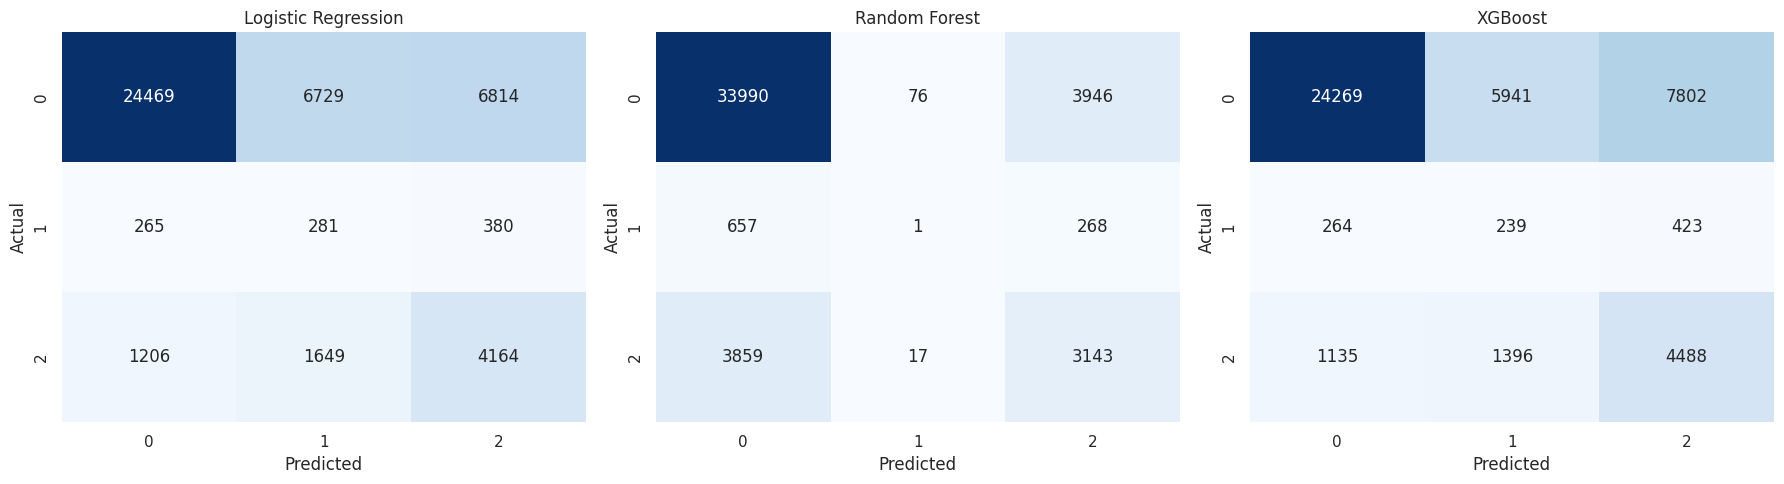

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 18. Per-Class Performance

In [21]:
per_class_rows = []
for model_name, pred in predictions.items():
    report = classification_report(
        y_test, pred,
        target_names=["No diabetes", "Prediabetes", "Diabetes"],
        output_dict=True, zero_division=0
    )
    for class_name in ["No diabetes", "Prediabetes", "Diabetes"]:
        per_class_rows.append({
            "Model": model_name,
            "Class": class_name,
            "Precision": report[class_name]["precision"],
            "Recall": report[class_name]["recall"],
            "F1": report[class_name]["f1-score"],
            "Support": int(report[class_name]["support"])
        })

per_class_df = pd.DataFrame(per_class_rows)
display(per_class_df.round(4))

,Model,Class,Precision,Recall,F1,Support
0,Logistic Regression,No diabetes,0.9433,0.6437,0.7652,38012
1,Logistic Regression,Prediabetes,0.0325,0.3035,0.0586,926
2,Logistic Regression,Diabetes,0.3666,0.5932,0.4532,7019
3,Random Forest,No diabetes,0.8827,0.8942,0.8884,38012
4,Random Forest,Prediabetes,0.0106,0.0011,0.0020,926
5,Random Forest,Diabetes,0.4272,0.4478,0.4373,7019
6,XGBoost,No diabetes,0.9455,0.6385,0.7622,38012
7,XGBoost,Prediabetes,0.0315,0.2581,0.0562,926
8,XGBoost,Diabetes,0.3530,0.6394,0.4549,7019


## 19. Feature Importance

In [22]:
rf_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns, name="Random Forest Importance"
).sort_values(ascending=False)

xgb_importance = pd.Series(
    xgb_model.feature_importances_, index=X.columns, name="XGBoost Importance"
).sort_values(ascending=False)

print("Top 15 Random Forest features:")
display(rf_importance.head(15).to_frame())

print("Top 15 XGBoost features:")
display(xgb_importance.head(15).to_frame())

Top 15 Random Forest features:


,Random Forest Importance
BMI,0.171707
Age,0.135984
Income,0.099723
PhysHlth,0.079671
Education,0.069555
GenHlth,0.068217
MentHlth,0.067689
HighBP,0.039080
Smoker,0.035781
Fruits,0.034565


Top 15 XGBoost features:


,XGBoost Importance
HighBP,0.265853
GenHlth,0.098571
HighChol,0.077012
Age,0.049540
CholCheck,0.044712
BMI,0.039260
HvyAlcoholConsump,0.037068
HeartDiseaseorAttack,0.034936
DiffWalk,0.034105
NoDocbcCost,0.032104


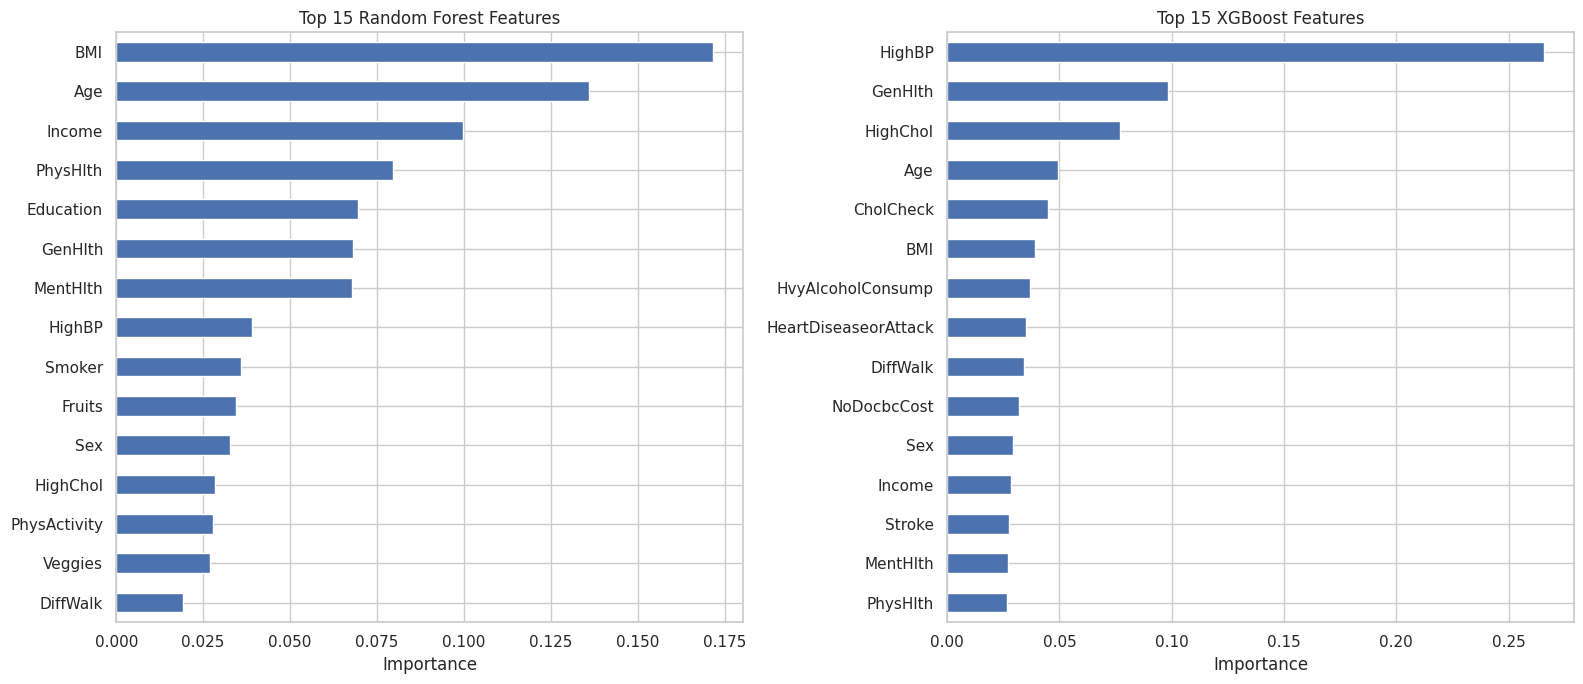

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

rf_importance.head(15).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 15 Random Forest Features")
axes[0].set_xlabel("Importance")

xgb_importance.head(15).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 15 XGBoost Features")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 20. Missing-Data Strategy

The supplied dataset contains **no missing values**, so no imputation was necessary.

If missing values had been present, appropriate strategies would depend on the variable:

| Variable type | Possible strategy | Reason |
|---|---|---|
| Continuous variable such as BMI | Median imputation | Robust to outliers |
| Binary indicator | Mode or explicit missing category | Preserves categorical meaning |
| Ordinal variable such as Income/Education | Median/ordinal-aware imputation | Respects ordering |
| Large/structured missingness | Investigate missingness mechanism first | Avoids inappropriate automatic imputation |

These are contingency strategies only; they were **not applied** to the supplied data.

## 21. Key Patterns, Anomalies, and Risk Indicators

### Key patterns
- The target is strongly imbalanced, with the no-diabetes group forming the majority.
- Exact duplicate rows are present in the raw data and were removed before modeling.
- BMI is higher on average in the prediabetes and diabetes groups.
- High blood pressure and high cholesterol are more prevalent in the diabetes-related groups.
- Physical activity is less prevalent in the diabetes-related groups.
- General health, age, difficulty walking, cardiovascular conditions, and other health indicators show measurable associations with diabetes status.

### Important modeling issue
The prediabetes class is much smaller than the other classes. Therefore, high accuracy alone can be misleading.

### Interpretation caution
These findings describe associations in observational survey data. They do not establish that a particular factor causes diabetes.

## 22. Final Assignment Summary

**Dataset and cleaning:** The supplied dataset contains 253,680 original rows and 22 columns. It contains no missing values. The raw dataset contains 23,899 exact duplicate rows; these were removed before modeling, leaving 229,781 observations.

**Target:** `Diabetes_012` is a three-class target representing no diabetes, prediabetes, and diabetes. The target is highly imbalanced, with prediabetes being the smallest class.

**EDA:** The analysis shows differences across diabetes-status groups for BMI, high blood pressure, high cholesterol, general health, physical activity, difficulty walking, and cardiovascular indicators.

**Modeling:** Logistic Regression, Random Forest, and XGBoost were trained using a stratified train/test split. Class balancing was incorporated where appropriate. Model comparison uses accuracy together with balanced accuracy, macro precision, macro recall, and macro F1.

**Risk indicators:** Variables such as general health, high blood pressure, BMI, high cholesterol, age, difficulty walking, cardiovascular conditions, and physical activity show useful associations with the target and/or contribute to model predictions.

**Limitations:** The dataset is observational and survey-based, and the encoded variables do not imply causation. The minority prediabetes class also makes class-sensitive evaluation essential.

## 23. Submission Checklist

- [x] Dataset loaded
- [x] Dataset dimensions and variables documented
- [x] Descriptive statistics
- [x] Missing-value analysis
- [x] Duplicate analysis and cleaning
- [x] Target distribution
- [x] Exploratory visualizations
- [x] Relationship/risk-factor analysis
- [x] Correlation analysis
- [x] Stratified train/test split
- [x] Logistic Regression
- [x] Random Forest
- [x] XGBoost
- [x] Accuracy, balanced accuracy, precision, recall and F1
- [x] Confusion matrices
- [x] Per-class analysis
- [x] Feature importance
- [x] Missing-data strategy
- [x] Key findings and limitations
- [x] Final report-style summary

**Before submission:** Run all cells from top to bottom so that the notebook contains the generated tables, plots, metrics, and model outputs.